### Librerias

In [2]:
import SimpleITK as sitk 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

### Introducción a la Parte C

En esta sección se analiza la calidad de las señales BOLD obtenidas a partir de imágenes fMRI preprocesadas mediante FEAT. En la Parte B del trabajo práctico se aplicaron tres configuraciones distintas:

- **Configuración 1**: Suavizado espacial de 5 mm FWHM y filtro pasa altos.
- **Configuración 2**: Igual a la anterior, pero con suavizado de 8 mm.
- **Configuración 3**: Igual a la configuración 1, pero sin filtro pasa altos, para observar los efectos de esta variación.

Todas las configuraciones utilizaron las imágenes `funcional_3s_30te_2_4_iso_estric_.nii.gz` como entrada. Se aplicaron correcciones por distorsión de campo (B0 unwarp) y registro no lineal para asegurar la correcta alineación entre imágenes funcionales y estructurales.

En la Parte C, se implementó un script en Python para visualizar las señales BOLD a nivel de vóxel, siguiendo el enfoque propuesto por Power (2017). Las imágenes fMRI se transformaron de formato 4D a una matriz 2D, donde cada fila representa la señal temporal de un vóxel. Luego se:

- Segmentaron las imágenes para conservar únicamente los vóxeles de materia gris y blanca.
- Ordenaron los vóxeles por tipo de tejido.
- Visualizaron las señales en una imagen en escala de grises.
- Calcularon los índices SNR y tSNR para evaluar la calidad de la señal.

Este análisis permite comparar el impacto de los distintos parámetros de preprocesamiento sobre la calidad de la señal BOLD.


# 1era Configuracion
Suavizado espacial de 5 mm FWHM y un filtro pasa altos.
## Files 

In [2]:
base_dir = Path(r'C:\Users\Notebook\Desktop\NeuroComp\tutorial\data')
subject_to_process = 'CP01182'
feat_output_subdir = '..feat'  
subject_dir = base_dir / subject_to_process
feat_dir = subject_dir / feat_output_subdir

filename_fmri = subject_dir / 'funcional_3s_30te_2_4_iso_estric__s014.nii.gz'
filename_t1 = subject_dir / 't1_robustfov.nii.gz'
filename_t1_brain = subject_dir / 't1_robustfov_brain.nii.gz'
filename_t1_brain_mask = subject_dir / 't1_robustfov_brain_mask.nii.gz'
filename_fast_seg = subject_dir / 't1_robustfov_brain_seg.nii.gz'
filename_fmri_to_t1 = feat_dir / 'reg' / 'example_func2highres.nii.gz'
filename_preprocessed_fmri = feat_dir / 'filtered_func_data.nii.gz'
filename_fmri_brain_mask = feat_dir / 'mask.nii.gz'
filename_fast_seg_in_fmri = feat_dir / 't1_seg_in_func_space.nii.gz'


fmri = sitk.ReadImage(str(filename_fmri))
t1 = sitk.ReadImage(str(filename_t1))
t1_brain = sitk.ReadImage(str(filename_t1_brain))  
t1_seg = sitk.ReadImage(str(filename_fast_seg))
fmri_to_t1 = sitk.ReadImage(str(filename_fmri_to_t1))
prep_fmri = sitk.ReadImage(str(filename_preprocessed_fmri))
fmri_brain_mask = sitk.ReadImage(str(filename_fmri_brain_mask))
t1_seg_in_fmri = sitk.ReadImage(str(filename_fast_seg_in_fmri))

### Convertir imagenes a NumpyArrays
Las fmri tiene 4D (y,x,z,t)

La ides es convertir la imagen fMRI de SimpleITK a un array NumPy.

Pero hay que tener cuidado que el orden en que SimpleITK entrega el array es: (t, z, y, x).

Asi que hay que cambiar ese orden

In [3]:
# Before preprocessing:

nda_fmri = sitk.GetArrayFromImage(fmri) # (z, t, y, x)
nda_fmri = np.transpose(nda_fmri, (2, 3, 1, 0)) # (y, x, t, z)

# After preprocessing:

nda_prep_fmri = sitk.GetArrayFromImage(prep_fmri)
nda_prep_fmri = np.transpose(nda_prep_fmri, (2, 3, 1, 0))

# Mascara de funcional:

nda_fmri_mask = sitk.GetArrayFromImage(fmri_brain_mask)
nda_fmri_mask = np.transpose(nda_fmri_mask, (1, 2, 0))

# t1 segmentation:

nda_t1_seg = sitk.GetArrayFromImage(t1_seg)
nda_t1_seg = np.transpose(nda_t1_seg, (1, 2, 0))

# t1 segmentation in functional space:

nda_t1_seg_in_fmri = sitk.GetArrayFromImage(t1_seg_in_fmri)
nda_t1_seg_in_fmri = np.transpose(nda_t1_seg_in_fmri, (1, 2, 0))

### Bold Signals
Los datos se normalizan
Se plotea la data de la preprocesada en su espacio nativo

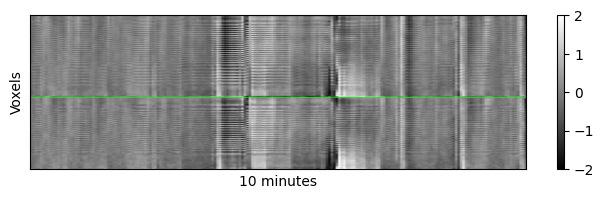

In [34]:
# Regresión para quitar fluctuaciones comunes
nda_prep_bold_signals = np.reshape(nda_prep_fmri, (-1, nda_fmri.shape[-1]))

# Matriz de regresión
r0 = np.ones((1, nda_prep_fmri.shape[-1]))
r1 = np.linspace(0, 1, num=nda_prep_fmri.shape[-1], axis=0)
r1 = np.expand_dims(r1, axis=1)
r = np.concatenate((r0, r1.T))

# Regresión lineal para eliminar fluctuaciones comunes
x, residuals, rank, s = np.linalg.lstsq(r.T, nda_prep_bold_signals.T, rcond=None)
pred = np.matmul(r.T, x)
nda_prep_bold_signals_reg = nda_prep_bold_signals - pred.T

# Usar solo voxeles en la materia gris y blanca con la máscara
nda_t1_seg_in_fmri_1d = np.reshape(nda_t1_seg_in_fmri, -1)

# Señales con regresión
nda_prep_bold_signals_reg_gm = nda_prep_bold_signals_reg[nda_t1_seg_in_fmri_1d == 2, :]
nda_prep_bold_signals_reg_wm = nda_prep_bold_signals_reg[nda_t1_seg_in_fmri_1d == 3, :]
nda_prep_bold_signals_reg_gm_wm = np.concatenate((nda_prep_bold_signals_reg_gm, nda_prep_bold_signals_reg_wm))

# Z-score con protección contra desviación estándar cero
mean_bolds = np.mean(nda_prep_bold_signals_reg_gm_wm, axis=1, keepdims=True)  # Keepdims para mantener la forma
std_bolds = np.std(nda_prep_bold_signals_reg_gm_wm, axis=1, keepdims=True)

# Evitar división por cero reemplazando la desviación estándar cero por un valor muy pequeño
std_bolds[std_bolds == 0] = np.finfo(float).eps

nda_prep_bold_signals_reg_gm_wm_norm = (nda_prep_bold_signals_reg_gm_wm - mean_bolds) / std_bolds

# Señales sin regresión
nda_prep_bold_signals_gm = nda_prep_bold_signals[nda_t1_seg_in_fmri_1d == 2, :]
nda_prep_bold_signals_wm = nda_prep_bold_signals[nda_t1_seg_in_fmri_1d == 3, :]
nda_prep_bold_signals_gm_wm = np.concatenate((nda_prep_bold_signals_gm, nda_prep_bold_signals_wm))

# Z-score sin regresión con protección contra desviación estándar cero
mean_bolds = np.mean(nda_prep_bold_signals_gm_wm, axis=1, keepdims=True)  # Keepdims para mantener la forma
std_bolds = np.std(nda_prep_bold_signals_gm_wm, axis=1, keepdims=True)

# Evitar división por cero reemplazando la desviación estándar cero por un valor muy pequeño
std_bolds[std_bolds == 0] = np.finfo(float).eps

nda_prep_bold_signals_gm_wm_norm = (nda_prep_bold_signals_gm_wm - mean_bolds) / std_bolds

# Calcular índice para la línea separadora
split_idx = nda_prep_bold_signals_reg_gm.shape[0]

# Plot
TR = 3
tiempos = np.arange(nda_prep_bold_signals_reg_gm_wm.shape[1]) * TR

plt.figure(figsize=(8, 2))
#plt.subplot(2,1,1)
img = plt.imshow(nda_prep_bold_signals_gm_wm_norm, cmap='gray', aspect='auto',vmin=-2, vmax=2, extent=[tiempos[0], tiempos[-1], nda_prep_bold_signals_gm_wm.shape[0], 0])
plt.axhline(split_idx , color='lime', linewidth=0.5)  
#plt.title("BOLD signals - without regression")
plt.xlabel("10 minutes")
plt.ylabel("Voxels")
plt.colorbar(img)
plt.yticks([])
plt.xticks([])



#plt.figure(figsize=(8, 2))
# plt.subplot(2,1,2)
# img = plt.imshow(nda_prep_bold_signals_reg_gm_wm, cmap='gray', aspect='auto', vmin=-20, vmax=20, extent=[tiempos[0], tiempos[-1], nda_prep_bold_signals_reg_gm_wm.shape[0], 0])
# plt.axhline(split_idx, color='lime', linewidth=0.5)  # Línea verde separadora
# #plt.title("BOLD signals")
# plt.xlabel("10 minutes")
# plt.ylabel("(b)", rotation=0, labelpad=15)
# plt.colorbar(img)
# plt.yticks([])
# plt.xticks([])
# #plt.tight_layout()
plt.show()




In [10]:
# Imagen promedio en el tiempo (desde fMRI preprocesada)
mean_image_prep = np.mean(nda_prep_fmri, axis=3)  # (x, y, z)
mean_image_prep_1d = mean_image_prep.flatten()

# Máscaras desde la segmentación anatómica en espacio funcional
mask_gm = nda_t1_seg_in_fmri.flatten() == 2  # materia gris
mask_bg = nda_t1_seg_in_fmri.flatten() == 0  # fondo (background)

# Señal: promedio de los valores en materia gris
signal_with_reg = np.mean(mean_image_prep_1d[mask_gm])
signal_no_reg = signal_with_reg  # La imagen promedio no cambia con regresión

# Ruido: desviación estándar del fondo
noise_with_reg = np.std(mean_image_prep_1d[mask_bg])
noise_no_reg = noise_with_reg

# Cálculo del SNR
snr_with_reg = signal_with_reg / noise_with_reg
snr_no_reg = signal_no_reg / noise_no_reg

print(f"SNR con regresión: {snr_with_reg:.4f}")
print(f"SNR sin regresión: {snr_no_reg:.4f}")


SNR con regresión: 7.3433
SNR sin regresión: 7.3433


In [23]:
# -- tSNR sin regresión --
mean_gm = np.mean(nda_prep_bold_signals_gm, axis=1)
std_gm = np.std(nda_prep_bold_signals_gm, axis=1)
valid_voxels = std_gm > 0
tsnr_gm = mean_gm[valid_voxels] / std_gm[valid_voxels]
mean_tsnr_no_reg = np.mean(tsnr_gm)

# -- tSNR con regresión --
mean_gm_reg = np.mean(nda_prep_bold_signals_reg_gm, axis=1)
std_gm_reg = np.std(nda_prep_bold_signals_reg_gm, axis=1)
valid_voxels_reg = std_gm_reg > 0
tsnr_gm_reg = mean_gm_reg[valid_voxels_reg] / std_gm_reg[valid_voxels_reg]
mean_tsnr_with_reg = np.mean(tsnr_gm_reg)

print(f"tSNR medio sin regresión: {mean_tsnr_no_reg:.4f}")
print(f"tSNR medio con regresión: {mean_tsnr_with_reg}")



tSNR medio sin regresión: 98.0384
tSNR medio con regresión: -1.0412796046281608e-14


# 2da Configuracion
Suavizado espacial de 8 mm FWHM y un filtro pasa altos.


In [3]:
base_dir = Path(r'C:\Users\Notebook\Desktop\NeuroComp\tutorial\data')
subject_to_process = 'CP01182'
feat_output_subdir = 'feat_2.feat'  
subject_dir = base_dir / subject_to_process
feat_dir = subject_dir / feat_output_subdir

filename_fmri = subject_dir / 'funcional_3s_30te_2_4_iso_estric__s014.nii.gz'
filename_t1 = subject_dir / 't1_robustfov.nii.gz'
filename_t1_brain = subject_dir / 't1_robustfov_brain.nii.gz'
filename_t1_brain_mask = subject_dir / 't1_robustfov_brain_mask.nii.gz'
filename_fast_seg = subject_dir / 't1_robustfov_brain_seg.nii.gz'
filename_fmri_to_t1 = feat_dir / 'reg' / 'example_func2highres.nii.gz'
filename_preprocessed_fmri = feat_dir / 'filtered_func_data.nii.gz'
filename_fmri_brain_mask = feat_dir / 'mask.nii.gz'
filename_fast_seg_in_fmri = feat_dir / 't1_seg_in_func_space.nii.gz'


fmri = sitk.ReadImage(str(filename_fmri))
t1 = sitk.ReadImage(str(filename_t1))
t1_brain = sitk.ReadImage(str(filename_t1_brain))  
t1_seg = sitk.ReadImage(str(filename_fast_seg))
fmri_to_t1 = sitk.ReadImage(str(filename_fmri_to_t1))
prep_fmri = sitk.ReadImage(str(filename_preprocessed_fmri))
fmri_brain_mask = sitk.ReadImage(str(filename_fmri_brain_mask))
t1_seg_in_fmri = sitk.ReadImage(str(filename_fast_seg_in_fmri))

In [4]:
# Before preprocessing:

nda_fmri = sitk.GetArrayFromImage(fmri) # (z, t, y, x)
nda_fmri = np.transpose(nda_fmri, (2, 3, 1, 0)) # (y, x, t, z)

# After preprocessing:

nda_prep_fmri = sitk.GetArrayFromImage(prep_fmri)
nda_prep_fmri = np.transpose(nda_prep_fmri, (2, 3, 1, 0))

# Mascara de funcional:

nda_fmri_mask = sitk.GetArrayFromImage(fmri_brain_mask)
nda_fmri_mask = np.transpose(nda_fmri_mask, (1, 2, 0))

# t1 segmentation:

nda_t1_seg = sitk.GetArrayFromImage(t1_seg)
nda_t1_seg = np.transpose(nda_t1_seg, (1, 2, 0))

# t1 segmentation in functional space:

nda_t1_seg_in_fmri = sitk.GetArrayFromImage(t1_seg_in_fmri)
nda_t1_seg_in_fmri = np.transpose(nda_t1_seg_in_fmri, (1, 2, 0))

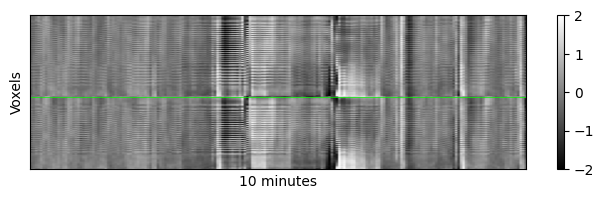

In [5]:
# Regresión para quitar fluctuaciones comunes
nda_prep_bold_signals = np.reshape(nda_prep_fmri, (-1, nda_fmri.shape[-1]))

# Matriz de regresión
r0 = np.ones((1, nda_prep_fmri.shape[-1]))
r1 = np.linspace(0, 1, num=nda_prep_fmri.shape[-1], axis=0)
r1 = np.expand_dims(r1, axis=1)
r = np.concatenate((r0, r1.T))

# Regresión lineal para eliminar fluctuaciones comunes
x, residuals, rank, s = np.linalg.lstsq(r.T, nda_prep_bold_signals.T, rcond=None)
pred = np.matmul(r.T, x)
nda_prep_bold_signals_reg = nda_prep_bold_signals - pred.T

# Usar solo voxeles en la materia gris y blanca con la máscara
nda_t1_seg_in_fmri_1d = np.reshape(nda_t1_seg_in_fmri, -1)

# Señales con regresión
nda_prep_bold_signals_reg_gm = nda_prep_bold_signals_reg[nda_t1_seg_in_fmri_1d == 2, :]
nda_prep_bold_signals_reg_wm = nda_prep_bold_signals_reg[nda_t1_seg_in_fmri_1d == 3, :]
nda_prep_bold_signals_reg_gm_wm = np.concatenate((nda_prep_bold_signals_reg_gm, nda_prep_bold_signals_reg_wm))

# Z-score con protección contra desviación estándar cero
mean_bolds = np.mean(nda_prep_bold_signals_reg_gm_wm, axis=1, keepdims=True)  # Keepdims para mantener la forma
std_bolds = np.std(nda_prep_bold_signals_reg_gm_wm, axis=1, keepdims=True)

# Evitar división por cero reemplazando la desviación estándar cero por un valor muy pequeño
std_bolds[std_bolds == 0] = np.finfo(float).eps

nda_prep_bold_signals_reg_gm_wm_norm = (nda_prep_bold_signals_reg_gm_wm - mean_bolds) / std_bolds

# Señales sin regresión
nda_prep_bold_signals_gm = nda_prep_bold_signals[nda_t1_seg_in_fmri_1d == 2, :]
nda_prep_bold_signals_wm = nda_prep_bold_signals[nda_t1_seg_in_fmri_1d == 3, :]
nda_prep_bold_signals_gm_wm = np.concatenate((nda_prep_bold_signals_gm, nda_prep_bold_signals_wm))

# Z-score sin regresión con protección contra desviación estándar cero
mean_bolds = np.mean(nda_prep_bold_signals_gm_wm, axis=1, keepdims=True)  # Keepdims para mantener la forma
std_bolds = np.std(nda_prep_bold_signals_gm_wm, axis=1, keepdims=True)

# Evitar división por cero reemplazando la desviación estándar cero por un valor muy pequeño
std_bolds[std_bolds == 0] = np.finfo(float).eps

nda_prep_bold_signals_gm_wm_norm = (nda_prep_bold_signals_gm_wm - mean_bolds) / std_bolds

# Calcular índice para la línea separadora
split_idx = nda_prep_bold_signals_reg_gm.shape[0]

# Plot
TR = 3
tiempos = np.arange(nda_prep_bold_signals_reg_gm_wm.shape[1]) * TR

plt.figure(figsize=(8, 2))
#plt.subplot(2,1,1)
img = plt.imshow(nda_prep_bold_signals_gm_wm_norm, cmap='gray', aspect='auto',vmin=-2, vmax=2, extent=[tiempos[0], tiempos[-1], nda_prep_bold_signals_gm_wm.shape[0], 0])
plt.axhline(split_idx , color='lime', linewidth=0.5)  # Línea verde separadora
#plt.title("BOLD signals - without regression")
plt.xlabel("10 minutes")
plt.ylabel("Voxels")
plt.colorbar(img)
plt.yticks([])
plt.xticks([])



#plt.figure(figsize=(8, 2))
# plt.subplot(2,1,2)
# img = plt.imshow(nda_prep_bold_signals_reg_gm_wm, cmap='gray', aspect='auto', vmin=-20, vmax=20, extent=[tiempos[0], tiempos[-1], nda_prep_bold_signals_reg_gm_wm.shape[0], 0])
# plt.axhline(split_idx, color='lime', linewidth=0.5)  # Línea verde separadora
# #plt.title("BOLD signals")
# plt.xlabel("10 minutes")
# plt.ylabel("(b)", rotation=0, labelpad=15)
# plt.colorbar(img)
# plt.yticks([])
# plt.xticks([])
# #plt.tight_layout()
plt.show()

In [6]:
# Imagen promedio en el tiempo (desde fMRI preprocesada)
mean_image_prep = np.mean(nda_prep_fmri, axis=3)  # (x, y, z)
mean_image_prep_1d = mean_image_prep.flatten()

# Máscaras desde la segmentación anatómica en espacio funcional
mask_gm = nda_t1_seg_in_fmri.flatten() == 2  # materia gris
mask_bg = nda_t1_seg_in_fmri.flatten() == 0  # fondo (background)

# Señal: promedio de los valores en materia gris
signal_with_reg = np.mean(mean_image_prep_1d[mask_gm])
signal_no_reg = signal_with_reg  # La imagen promedio no cambia con regresión

# Ruido: desviación estándar del fondo
noise_with_reg = np.std(mean_image_prep_1d[mask_bg])
noise_no_reg = noise_with_reg

# Cálculo del SNR
snr_with_reg = signal_with_reg / noise_with_reg
snr_no_reg = signal_no_reg / noise_no_reg

print(f"SNR con regresión: {snr_with_reg:.4f}")
print(f"SNR sin regresión: {snr_no_reg:.4f}")

SNR con regresión: 7.5618
SNR sin regresión: 7.5618


In [7]:
# -- tSNR sin regresión --
mean_gm = np.mean(nda_prep_bold_signals_gm, axis=1)
std_gm = np.std(nda_prep_bold_signals_gm, axis=1)
valid_voxels = std_gm > 0
tsnr_gm = mean_gm[valid_voxels] / std_gm[valid_voxels]
mean_tsnr_no_reg = np.mean(tsnr_gm)

# -- tSNR con regresión --
mean_gm_reg = np.mean(nda_prep_bold_signals_reg_gm, axis=1)
std_gm_reg = np.std(nda_prep_bold_signals_reg_gm, axis=1)
valid_voxels_reg = std_gm_reg > 0
tsnr_gm_reg = mean_gm_reg[valid_voxels_reg] / std_gm_reg[valid_voxels_reg]
mean_tsnr_with_reg = np.mean(tsnr_gm_reg)

print(f"tSNR medio sin regresión: {mean_tsnr_no_reg:.4f}")
print(f"tSNR medio con regresión: {mean_tsnr_with_reg}")

tSNR medio sin regresión: 123.6028
tSNR medio con regresión: -1.2992938068667336e-14


# 3era Configuracion
Suavizado espacial de 5 mm FWHM y sin filtro pasa altos.

In [3]:
base_dir = Path(r'C:\Users\Notebook\Desktop\NeuroComp\tutorial\data')
subject_to_process = 'CP01182'
feat_output_subdir = 'sinpasaaltos..feat'  
subject_dir = base_dir / subject_to_process
feat_dir = subject_dir / feat_output_subdir

filename_fmri = subject_dir / 'funcional_3s_30te_2_4_iso_estric__s014.nii.gz'
filename_t1 = subject_dir / 't1_robustfov.nii.gz'
filename_t1_brain = subject_dir / 't1_robustfov_brain.nii.gz'
filename_t1_brain_mask = subject_dir / 't1_robustfov_brain_mask.nii.gz'
filename_fast_seg = subject_dir / 't1_robustfov_brain_seg.nii.gz'
filename_fmri_to_t1 = feat_dir / 'reg' / 'example_func2highres.nii.gz'
filename_preprocessed_fmri = feat_dir / 'filtered_func_data.nii.gz'
filename_fmri_brain_mask = feat_dir / 'mask.nii.gz'
filename_fast_seg_in_fmri = feat_dir / 't1_seg_in_func_space.nii.gz'


fmri = sitk.ReadImage(str(filename_fmri))
t1 = sitk.ReadImage(str(filename_t1))
t1_brain = sitk.ReadImage(str(filename_t1_brain))  
t1_seg = sitk.ReadImage(str(filename_fast_seg))
fmri_to_t1 = sitk.ReadImage(str(filename_fmri_to_t1))
prep_fmri = sitk.ReadImage(str(filename_preprocessed_fmri))
fmri_brain_mask = sitk.ReadImage(str(filename_fmri_brain_mask))
t1_seg_in_fmri = sitk.ReadImage(str(filename_fast_seg_in_fmri))

In [4]:
# Before preprocessing:

nda_fmri = sitk.GetArrayFromImage(fmri) # (z, t, y, x)
nda_fmri = np.transpose(nda_fmri, (2, 3, 1, 0)) # (y, x, t, z)

# After preprocessing:

nda_prep_fmri = sitk.GetArrayFromImage(prep_fmri)
nda_prep_fmri = np.transpose(nda_prep_fmri, (2, 3, 1, 0))

# Mascara de funcional:

nda_fmri_mask = sitk.GetArrayFromImage(fmri_brain_mask)
nda_fmri_mask = np.transpose(nda_fmri_mask, (1, 2, 0))

# t1 segmentation:

nda_t1_seg = sitk.GetArrayFromImage(t1_seg)
nda_t1_seg = np.transpose(nda_t1_seg, (1, 2, 0))

# t1 segmentation in functional space:

nda_t1_seg_in_fmri = sitk.GetArrayFromImage(t1_seg_in_fmri)
nda_t1_seg_in_fmri = np.transpose(nda_t1_seg_in_fmri, (1, 2, 0))

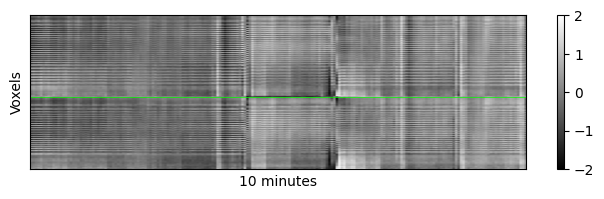

In [5]:
# Regresión para quitar fluctuaciones comunes
nda_prep_bold_signals = np.reshape(nda_prep_fmri, (-1, nda_fmri.shape[-1]))

# Matriz de regresión
r0 = np.ones((1, nda_prep_fmri.shape[-1]))
r1 = np.linspace(0, 1, num=nda_prep_fmri.shape[-1], axis=0)
r1 = np.expand_dims(r1, axis=1)
r = np.concatenate((r0, r1.T))

# Regresión lineal para eliminar fluctuaciones comunes
x, residuals, rank, s = np.linalg.lstsq(r.T, nda_prep_bold_signals.T, rcond=None)
pred = np.matmul(r.T, x)
nda_prep_bold_signals_reg = nda_prep_bold_signals - pred.T

# Usar solo voxeles en la materia gris y blanca con la máscara
nda_t1_seg_in_fmri_1d = np.reshape(nda_t1_seg_in_fmri, -1)

# Señales con regresión
nda_prep_bold_signals_reg_gm = nda_prep_bold_signals_reg[nda_t1_seg_in_fmri_1d == 2, :]
nda_prep_bold_signals_reg_wm = nda_prep_bold_signals_reg[nda_t1_seg_in_fmri_1d == 3, :]
nda_prep_bold_signals_reg_gm_wm = np.concatenate((nda_prep_bold_signals_reg_gm, nda_prep_bold_signals_reg_wm))

# Z-score con protección contra desviación estándar cero
mean_bolds = np.mean(nda_prep_bold_signals_reg_gm_wm, axis=1, keepdims=True)  # Keepdims para mantener la forma
std_bolds = np.std(nda_prep_bold_signals_reg_gm_wm, axis=1, keepdims=True)

# Evitar división por cero reemplazando la desviación estándar cero por un valor muy pequeño
std_bolds[std_bolds == 0] = np.finfo(float).eps

nda_prep_bold_signals_reg_gm_wm_norm = (nda_prep_bold_signals_reg_gm_wm - mean_bolds) / std_bolds

# Señales sin regresión
nda_prep_bold_signals_gm = nda_prep_bold_signals[nda_t1_seg_in_fmri_1d == 2, :]
nda_prep_bold_signals_wm = nda_prep_bold_signals[nda_t1_seg_in_fmri_1d == 3, :]
nda_prep_bold_signals_gm_wm = np.concatenate((nda_prep_bold_signals_gm, nda_prep_bold_signals_wm))

# Z-score sin regresión con protección contra desviación estándar cero
mean_bolds = np.mean(nda_prep_bold_signals_gm_wm, axis=1, keepdims=True)  # Keepdims para mantener la forma
std_bolds = np.std(nda_prep_bold_signals_gm_wm, axis=1, keepdims=True)

# Evitar división por cero reemplazando la desviación estándar cero por un valor muy pequeño
std_bolds[std_bolds == 0] = np.finfo(float).eps

nda_prep_bold_signals_gm_wm_norm = (nda_prep_bold_signals_gm_wm - mean_bolds) / std_bolds

# Calcular índice para la línea separadora
split_idx = nda_prep_bold_signals_reg_gm.shape[0]

# Plot
TR = 3
tiempos = np.arange(nda_prep_bold_signals_reg_gm_wm.shape[1]) * TR

plt.figure(figsize=(8, 2))
#plt.subplot(2,1,1)
img = plt.imshow(nda_prep_bold_signals_gm_wm_norm, cmap='gray', aspect='auto',vmin=-2, vmax=2, extent=[tiempos[0], tiempos[-1], nda_prep_bold_signals_gm_wm.shape[0], 0])
plt.axhline(split_idx , color='lime', linewidth=0.5)  # Línea verde separadora
#plt.title("BOLD signals - without regression")
plt.xlabel("10 minutes")
plt.ylabel("Voxels")
plt.colorbar(img)
plt.yticks([])
plt.xticks([])



#plt.figure(figsize=(8, 2))
# plt.subplot(2,1,2)
# img = plt.imshow(nda_prep_bold_signals_reg_gm_wm, cmap='gray', aspect='auto', vmin=-20, vmax=20, extent=[tiempos[0], tiempos[-1], nda_prep_bold_signals_reg_gm_wm.shape[0], 0])
# plt.axhline(split_idx, color='lime', linewidth=0.5)  # Línea verde separadora
# #plt.title("BOLD signals")
# plt.xlabel("10 minutes")
# plt.ylabel("(b)", rotation=0, labelpad=15)
# plt.colorbar(img)
# plt.yticks([])
# plt.xticks([])
# #plt.tight_layout()
plt.show()

In [6]:
# Imagen promedio en el tiempo (desde fMRI preprocesada)
mean_image_prep = np.mean(nda_prep_fmri, axis=3)  # (x, y, z)
mean_image_prep_1d = mean_image_prep.flatten()

# Máscaras desde la segmentación anatómica en espacio funcional
mask_gm = nda_t1_seg_in_fmri.flatten() == 2  # materia gris
mask_bg = nda_t1_seg_in_fmri.flatten() == 0  # fondo (background)

# Señal: promedio de los valores en materia gris
signal_with_reg = np.mean(mean_image_prep_1d[mask_gm])
signal_no_reg = signal_with_reg  # La imagen promedio no cambia con regresión

# Ruido: desviación estándar del fondo
noise_with_reg = np.std(mean_image_prep_1d[mask_bg])
noise_no_reg = noise_with_reg

# Cálculo del SNR
snr_with_reg = signal_with_reg / noise_with_reg
snr_no_reg = signal_no_reg / noise_no_reg

print(f"SNR con regresión: {snr_with_reg:.4f}")
print(f"SNR sin regresión: {snr_no_reg:.4f}")

SNR con regresión: 7.3502
SNR sin regresión: 7.3502


In [7]:
# -- tSNR sin regresión --
mean_gm = np.mean(nda_prep_bold_signals_gm, axis=1)
std_gm = np.std(nda_prep_bold_signals_gm, axis=1)
valid_voxels = std_gm > 0
tsnr_gm = mean_gm[valid_voxels] / std_gm[valid_voxels]
mean_tsnr_no_reg = np.mean(tsnr_gm)

# -- tSNR con regresión --
mean_gm_reg = np.mean(nda_prep_bold_signals_reg_gm, axis=1)
std_gm_reg = np.std(nda_prep_bold_signals_reg_gm, axis=1)
valid_voxels_reg = std_gm_reg > 0
tsnr_gm_reg = mean_gm_reg[valid_voxels_reg] / std_gm_reg[valid_voxels_reg]
mean_tsnr_with_reg = np.mean(tsnr_gm_reg)

print(f"tSNR medio sin regresión: {mean_tsnr_no_reg:.4f}")
print(f"tSNR medio con regresión: {mean_tsnr_with_reg}")

tSNR medio sin regresión: 69.5215
tSNR medio con regresión: -8.571965641800298e-15
